In [1]:
import os
try:
    path_initialized
except NameError:
    path_initialized = True
    os.chdir('..')

import numpy as np
from sympy.abc import x, y

# from qldpc import codes
import networkx as nx
import matplotlib.pyplot as plt

import src.device as device
import src.plotting as plotter
from src.RotatedSurfaceCode import RotatedSurfaceCode
from src.HGPCode import HGPCode
from src.QECCode import TestCode

In [2]:
dev = device.UnitCellDevice(3,1, device.hardware_params(1e-3), debug=True)
code = TestCode(2, 1)
code.add_row_check(0)
code.add_row_check(0)
code.add_row_check(0)
# code.add_row_check(0)
# code.add_row_check(0)

data_coords = {0: (0,0), 1: (2,0)}
sched = dev.compile_QEC_schedule(
    code,
    data_coords,
    [],# code.check_cx_layers,
    rounds=1,
    use_highways=True,
    refocus_shuttle_noise=False,
    optimize_ancilla_start=True,
    buffer_time=10
)

[2, 3, 4]
Start nodes:
State(x=1, y=0, component=READOUT, t_start=0, t_end=10000000000, cur_task=(False, False))
State(x=0, y=0, component=READOUT, t_start=0, t_end=10000000000, cur_task=(False, False))
State(x=2, y=0, component=READOUT, t_start=0, t_end=10000000000, cur_task=(False, False))
POP (0, 0, 'READOUT', (False, False)) with cost 2600 (500 + 2600)
	ADD (0, 0, 'INTERACTION_ZONE', (False, False)) FROM (0, 0, 'READOUT', (False, False)) WITH COST 100
		estimated cost: 3400
	ADD (0, 0, 'SHUTTLE_INTERSECTION', (False, False)) FROM (0, 0, 'READOUT', (False, False)) WITH COST 100
		estimated cost: 3200
POP (2, 0, 'READOUT', (False, False)) with cost 2600 (500 + 2600)
	ADD (2, 0, 'INTERACTION_ZONE', (False, False)) FROM (2, 0, 'READOUT', (False, False)) WITH COST 100
		estimated cost: 3400
	ADD (2, 0, 'SHUTTLE_INTERSECTION', (False, False)) FROM (2, 0, 'READOUT', (False, False)) WITH COST 100
		estimated cost: 3200
POP (0, 0, 'SHUTTLE_INTERSECTION', (False, False)) with cost 3200 (600 

In [3]:
for instr,t in zip(sched.instructions, sched.instruction_start_times):
    print(t, instr)

0 Instantiate(duration=500, error=0.001, qubits=[0, 1], cell_coords=[(0, 0), (2, 0)])
500 EmplaceDisplace(duration=100, error=1e-06, qubit=0, coords=(0, 0), start_component=READOUT, end_component=INTERACTION_ZONE)
500 EmplaceDisplace(duration=100, error=1e-06, qubit=1, coords=(2, 0), start_component=READOUT, end_component=INTERACTION_ZONE)
600 Instantiate(duration=500, error=0.001, qubits=[2], cell_coords=[(2, 0)])
1100 EmplaceDisplace(duration=100, error=1e-06, qubit=2, coords=(2, 0), start_component=READOUT, end_component=INTERACTION_ZONE)
1200 Gate(duration=100, error=0.001, qubits=[1, 2], name=GateName.CX)
1300 EmplaceDisplace(duration=100, error=1e-06, qubit=2, coords=(2, 0), start_component=INTERACTION_ZONE, end_component=SHUTTLE_INTERSECTION)
1400 Shuttle(duration=1000, error=1e-05, qubit=2, start_coords=(2, 0), end_coords=(1, 0))
2400 Shuttle(duration=1000, error=1e-05, qubit=2, start_coords=(1, 0), end_coords=(0, 0))
3400 EmplaceDisplace(duration=100, error=1e-06, qubit=2, coo

MovieWriter imagemagick unavailable; using Pillow instead.


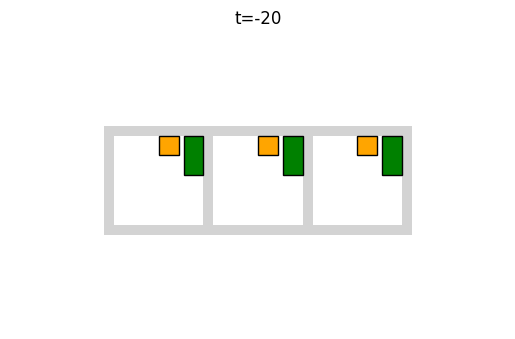

In [4]:
frames = sched.get_frames(20)
# plotter.plot_device_snapshot(dev, code, frames[123])
anim = plotter.animate_device(dev, code, frames, 'anim_test.gif', fps=30)

In [5]:
frames_dense = sched.get_frames(1)

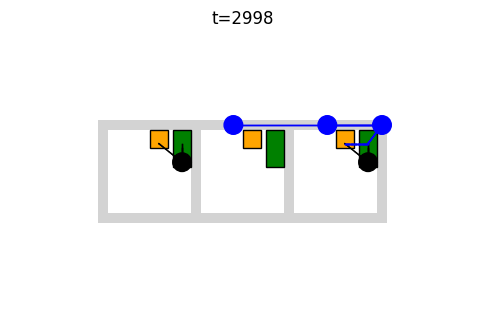

In [8]:
plotter.plot_transition(dev, code, frames_dense[0:3000])

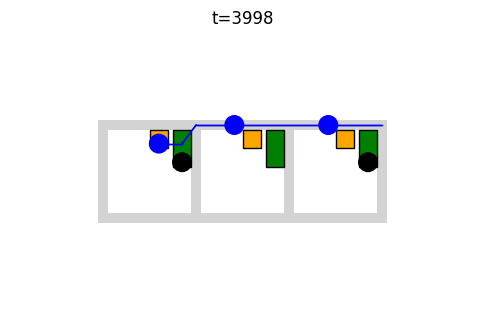

In [9]:
plotter.plot_transition(dev, code, frames_dense[3000:4000])